## COVID Random Forest: Predict Whether a Patient Has COVID

**Goal:** Binary classification (Result: positive vs negative) using symptoms and demographics.

**Setup:** 60% train / 40% test, **random_state=321**, stratified split. To keep tuning fast with ~1M rows: **tune on a 60k stratified sample** with **RandomizedSearchCV** (30 candidates, 5-fold CV); then **refit the best model on the full training set** and evaluate on the held-out test set. Class weight balanced for imbalance (~90% negative, ~10% positive).

**Why not accuracy for tuning?** With ~90% negative, accuracy is misleading (a model that always predicts "negative" gets ~90% accuracy). This notebook uses **scoring='f1'** in RandomizedSearchCV to optimize the positive class. The evaluation and feature-importance cells use the fitted model (`best_f1`).

### 1. Data load and imports

In [20]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report
import matplotlib.pyplot as plt

# Run from the Covid Project folder so this path finds the CSV
DATA_PATH = '../data/COVID_DATA_cleaned.csv'
df = pd.read_csv(DATA_PATH)
df.head(10)

,Cough,Fever,Sore_Throat,Shortness_Of_Breath,Headache,Age_60_And_Above,Sex,Contact,Result
0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,1,0,1,0
6,0,0,0,0,0,0,0,1,1
7,0,0,0,0,0,0,1,1,1
8,0,0,0,0,0,1,0,1,0
9,0,0,0,0,0,0,1,0,0


### 2. Train/test split

In [21]:
X = df.drop(columns=['Result'])
y = df['Result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=321, stratify=y)
print('Train:', len(X_train), '| Test (validation):', len(X_test))
print('Train % positive:', f'{y_train.mean()*100:.2f}%')
print('Test % positive:', f'{y_test.mean()*100:.2f}%')

Train: 587095 | Test (validation): 391398
Train % positive: 10.53%
Test % positive: 10.53%


### 3. Tuning sample

In [22]:
TUNE_SAMPLE_SIZE = 60_000

X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    train_size=TUNE_SAMPLE_SIZE,
    stratify=y_train,
    random_state=321
)

print(f"Tuning on {len(X_tune):,} sampled rows (full train has {len(X_train):,})")

Tuning on 60,000 sampled rows (full train has 587,095)


### 4. Hyperparameter tuning (F1) with RandomizedSearchCV

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=321, class_weight="balanced")

param_distributions = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [6, 8, 10, 14, None],
    "max_features": ["sqrt", "log2"],
    "min_samples_leaf": [1, 5, 10, 25, 50],
    "min_samples_split": [2, 5, 10, 25, 50],
}

search_f1 = RandomizedSearchCV(
    rf,
    param_distributions,
    n_iter=30,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    random_state=321,
    verbose=1,
)
search_f1.fit(X_tune, y_tune)
best_f1 = search_f1.best_estimator_
best_f1.fit(X_train, y_train)
print("Best F1 params:", search_f1.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best F1 params: {'n_estimators': 200, 'min_samples_split': 50, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 8}


### 5. Evaluation on test set

Get predicted probabilities, then run the threshold sweep and evaluate at a chosen threshold.

### 6. Threshold sweep (pick recall vs precision tradeoff)

In [24]:
model = best_f1 if 'best_f1' in dir() else best
y_proba = model.predict_proba(X_test)[:, 1]

for t in [0.30, 0.35, 0.355, 0.36, 0.365, 0.37, 0.375, 0.38,0.40]:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    print(f"t={t:.4f}  recall={recall:.3f}  precision={precision:.3f}  fp={fp:,}  fn={fn:,}")

t=0.3000  recall=0.794  precision=0.156  fp=176,591  fn=8,492
t=0.3500  recall=0.794  precision=0.156  fp=176,591  fn=8,492
t=0.3550  recall=0.576  precision=0.393  fp=36,742  fn=17,472
t=0.3600  recall=0.576  precision=0.393  fp=36,742  fn=17,472
t=0.3650  recall=0.542  precision=0.599  fp=14,917  fn=18,888
t=0.3700  recall=0.542  precision=0.599  fp=14,917  fn=18,888
t=0.3750  recall=0.542  precision=0.599  fp=14,917  fn=18,888
t=0.3800  recall=0.542  precision=0.599  fp=14,917  fn=18,888
t=0.4000  recall=0.542  precision=0.599  fp=14,917  fn=18,888


### 7. Evaluation at chosen threshold

In [25]:
threshold = 0.355 # change based on sweep above if desired
y_pred_custom = (y_proba >= threshold).astype(int)

acc = accuracy_score(y_test, y_pred_custom)
cm = confusion_matrix(y_test, y_pred_custom)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
auc = roc_auc_score(y_test, y_proba)

print("On validation (test) data:")
print("  Overall accuracy:", f"{acc:.4f}")
print("  Sensitivity (recall positive):", f"{sensitivity:.4f}")
print("  Specificity (recall negative):", f"{specificity:.4f}")
print("  AUC:", f"{auc:.4f}")
print("Confusion matrix (rows=actual, cols=pred) [Neg, Pos]:")
print(cm)
print(classification_report(y_test, y_pred_custom, target_names=["negative", "positive"]))

On validation (test) data:
  Overall accuracy: 0.8615
  Sensitivity (recall positive): 0.5761
  Specificity (recall negative): 0.8951
  AUC: 0.7695
Confusion matrix (rows=actual, cols=pred) [Neg, Pos]:
[[313443  36742]
 [ 17472  23741]]
              precision    recall  f1-score   support

    negative       0.95      0.90      0.92    350185
    positive       0.39      0.58      0.47     41213

    accuracy                           0.86    391398
   macro avg       0.67      0.74      0.69    391398
weighted avg       0.89      0.86      0.87    391398



### 8. Feature importance

In [26]:
model = best_f1 if 'best_f1' in dir() else best
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Feature importance:')
print(imp)
print('\nMost important predictor:', imp.idxmax())

Feature importance:
Contact                0.509745
Fever                  0.157544
Headache               0.154943
Cough                  0.103493
Sore_Throat            0.050126
Shortness_Of_Breath    0.013576
Sex                    0.009682
Age_60_And_Above       0.000892
dtype: float64

Most important predictor: Contact


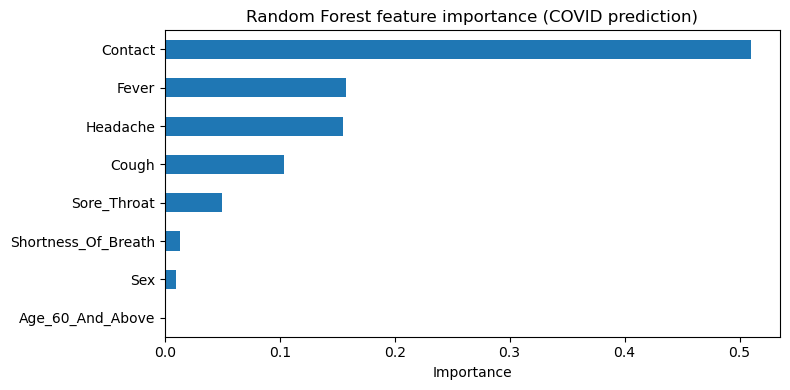

Exception ignored in: <function ResourceTracker.__del__ at 0x10769dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107061bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106631bc0>
Traceback (most recent call last

In [27]:
imp.sort_values(ascending=True).plot(kind='barh', figsize=(8, 4), title='Random Forest feature importance (COVID prediction)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Recommendations for this type of data

1. **Stratified split** — Keep class proportions in train/test (we did this). Important when one class is rare.
2. **Class weight** — Use `class_weight='balanced'` so the model does not ignore the minority (positive) class.
3. **Metrics** — Don’t use accuracy alone for model selection when data are imbalanced. This notebook tunes with **F1**; you can also use **ROC-AUC** and refit as `best`. Report **sensitivity** (recall for positive), **specificity**, and **AUC** on the test set, especially with ~90% negative.
4. **Feature importance** — The RF importance plot shows which symptoms/demographics matter most; useful for interpretation and potential feature reduction.
5. **Optional** — Try other models (e.g. logistic regression, gradient boosting) and compare AUC; consider SMOTE or undersampling if you need more positive examples during training.